# Реализация кода из статьи [Improving Adversarial Transferability via Neuron Attribution-Based Attacks](https://arxiv.org/pdf/2204.00008)

### Импорты и базовая конфигурация
Подключаем библиотеки, включаем градиенты и определяем устройство для вычислений.


In [1]:
import math
import gc

import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO
from torch.func import jvp

torch.set_grad_enabled(True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu")
DTYPE = torch.float32

print("device:", DEVICE)
print("torch:", torch.__version__)

device: mps
torch: 2.9.1


### Загрузка модели классификации
Инициализируем YOLO-классификатор, переводим модель на нужное устройство и проверяем классы.


In [2]:
# Загрузка классификатора
yolo = YOLO("yolo11s-cls.pt")
model = yolo.model.to(DEVICE).eval()
class_names = yolo.names

print(type(model).__name__)
print("num classes:", len(class_names))
print("first 10 classes:", {k: class_names[k] for k in range(10)})

ClassificationModel
num classes: 1000
first 10 classes: {0: 'tench', 1: 'goldfish', 2: 'great_white_shark', 3: 'tiger_shark', 4: 'hammerhead', 5: 'electric_ray', 6: 'stingray', 7: 'cock', 8: 'hen', 9: 'ostrich'}


### Подготовка входа и служебные утилиты
Определяем размер изображения, функции загрузки/препроцессинга и очистки кэша backend.


In [3]:
IMG_SIZE = 224
DEFAULT_LAYER_NAME = "model.9"

def load_image(path, img_size=IMG_SIZE, pad_value=0.0):
    """Load an image, apply letterbox-style resizing, and return both tensor and padded RGB array."""
    img = Image.open(path).convert("RGB")
    img_np = np.asarray(img).astype(np.float32) / 255.0
    h, w = img_np.shape[:2]
    if h == 0 or w == 0:
        raise ValueError(f"Некорректный размер изображения: {(h, w)}")

    scale = img_size / max(h, w)
    new_h = max(1, int(round(h * scale)))
    new_w = max(1, int(round(w * scale)))

    resized = np.asarray(
        Image.fromarray((img_np * 255).astype(np.uint8)).resize((new_w, new_h), Image.Resampling.BILINEAR)
    ).astype(np.float32) / 255.0

    canvas = np.full((img_size, img_size, 3), pad_value, dtype=np.float32)
    top = (img_size - new_h) // 2
    left = (img_size - new_w) // 2
    canvas[top:top + new_h, left:left + new_w] = resized

    x = torch.from_numpy(canvas).permute(2, 0, 1).unsqueeze(0).to(DEVICE, DTYPE)
    return x, canvas


def black_baseline_like(x):
    """Create a zero baseline tensor with the same shape and device as the input."""
    return torch.zeros_like(x)

def list_named_modules(model):
    """Return all non-empty named submodules of the given model."""
    return [(name, module) for name, module in model.named_modules() if name != ""]

def clear_backend_cache():
    """Trigger Python garbage collection and clear CUDA/MPS caches when available."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    if hasattr(torch, "mps") and torch.mps.is_available():
        try:
            torch.mps.empty_cache()
        except Exception:
            pass

def print_named_modules_detailed(model, max_name_len=45):
    """Print a detailed list of all named submodules with their types."""
    rows = []
    for name, module in model.named_modules():
        if name == "":
            continue
        rows.append((name, type(module).__name__))

    print(f"{'idx':>4}  {'module name':<{max_name_len}}  type")
    print("-" * (max_name_len + 20))
    for i, (name, typ) in enumerate(rows):
        short_name = name if len(name) <= max_name_len else name[:max_name_len - 3] + "..."
        print(f"{i:4d}  {short_name:<{max_name_len}}  {typ}")

    return rows


all_modules = print_named_modules_detailed(model)

 idx  module name                                    type
-----------------------------------------------------------------
   0  model                                          Sequential
   1  model.0                                        Conv
   2  model.0.conv                                   Conv2d
   3  model.0.bn                                     BatchNorm2d
   4  model.0.act                                    SiLU
   5  model.1                                        Conv
   6  model.1.conv                                   Conv2d
   7  model.1.bn                                     BatchNorm2d
   8  model.2                                        C3k2
   9  model.2.cv1                                    Conv
  10  model.2.cv1.conv                               Conv2d
  11  model.2.cv1.bn                                 BatchNorm2d
  12  model.2.cv2                                    Conv
  13  model.2.cv2.conv                               Conv2d
  14  model.2.cv2.bn         

### Хуки, парсинг выходов и визуализация
Добавляем вспомогательные функции для получения активаций слоя, агрегации и построения карт attribution.


In [4]:
# Вспомогательные утилиты для layer hook, output parsing и plotting

def split_classifier_output(out):
    """Normalize classifier output into a tuple of optional probabilities and logits tensor."""
    if isinstance(out, (tuple, list)):
        if len(out) >= 2 and torch.is_tensor(out[1]):
            return out[0], out[1]
        if len(out) >= 1 and torch.is_tensor(out[0]):
            return None, out[0]
    if torch.is_tensor(out):
        return None, out
    raise TypeError(f"Не удалось интерпретировать output классификатора типа {type(out).__name__}")

def unwrap_tensor(output):
    """Extract the first tensor object from a model output container."""
    if torch.is_tensor(output):
        return output
    if isinstance(output, (list, tuple)):
        for item in output:
            if torch.is_tensor(item):
                return item
    raise TypeError(f"Не удалось извлечь tensor activation из output типа {type(output).__name__}")

class LayerHook:
    def __init__(self, model, layer_name):
        """Initialize a forward hook for the selected layer and allocate activation storage."""
        self.layer_name = layer_name
        self.layer_store = {}
        modules = dict(model.named_modules())
        if layer_name not in modules:
            raise KeyError(f"Слой '{layer_name}' не найден в model.named_modules()")
        self.handle = modules[layer_name].register_forward_hook(self._hook)

    def _hook(self, module, inp, out):
        """Store the latest hooked layer output during forward execution."""
        self.layer_store[self.layer_name] = out

    def clear(self):
        """Clear cached layer activations from the hook storage."""
        self.layer_store.clear()

    def get(self):
        """Return the latest cached activation for the hooked layer."""
        return self.layer_store[self.layer_name]

    def remove(self):
        """Detach the forward hook from the model layer."""
        self.handle.remove()

def reduce_filter_scores(cond_tensor):
    """Aggregate attribution over non-filter axes to produce one score per filter."""
    if cond_tensor.ndim < 2:
        raise ValueError(
            f"Ожидался tensor с batch-осью и хотя бы одной feature-осью, получено shape={tuple(cond_tensor.shape)}"
        )

    per_sample = cond_tensor[0]
    if per_sample.ndim == 1:
        return per_sample

    reduce_dims = tuple(range(1, per_sample.ndim))
    return per_sample.sum(dim=reduce_dims)

def _normalize_map(arr):
    """Normalize a 2D map by its maximum absolute value for stable visualization."""
    arr = arr.astype(np.float32)
    max_abs = np.max(np.abs(arr))
    if max_abs > 0:
        arr = arr / max_abs
    return arr

def _resize_map_nearest(arr, out_hw):
    # Без сглаживания: nearest-neighbor upsampling
    """Resize a 2D map to target height and width using nearest-neighbor sampling."""
    h_out, w_out = out_hw
    h_in, w_in = arr.shape

    row_idx = np.floor(np.arange(h_out) * (h_in / h_out)).astype(int)
    col_idx = np.floor(np.arange(w_out) * (w_in / w_out)).astype(int)

    row_idx = np.clip(row_idx, 0, h_in - 1)
    col_idx = np.clip(col_idx, 0, w_in - 1)

    return arr[row_idx][:, col_idx]

def plot_total_attribution_overlay(image_np, cond_tensor, title=None):
    """Plot an image with an overlay of total spatial attribution summed over filters."""
    cond_np = cond_tensor[0].detach().cpu().numpy()

    if cond_np.ndim < 3:
        print("Общий spatial plot пропущен: у слоя нет пространственных осей.")
        return

    # Общая spatial attribution:
    # сумма по фильтрам |Cond_{c,h,w}|
    total_map = cond_np.sum(axis=0)
    total_map = _normalize_map(total_map)
    total_map = _resize_map_nearest(total_map, image_np.shape[:2])

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(image_np, interpolation="nearest")
    heat = ax.imshow(total_map, cmap="seismic", vmin=-1.0, vmax=1.0, alpha=0.45, interpolation="nearest")
    ax.axis("off")
    ax.set_title(title or "Total attribution overlay")

    cbar = fig.colorbar(heat, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Normalized attribution", rotation=90)

    plt.show()

def plot_top_filter_overlays(image_np, cond_tensor, filter_scores, top_idx, top_n=5):
    """Plot attribution overlays for the top-ranked filters on the input image."""
    cond_np = cond_tensor[0].detach().cpu().numpy()

    if cond_np.ndim < 3:
        print("Spatial overlays для отдельных фильтров пропущены: у слоя нет пространственных осей.")
        return

    top_n = min(top_n, len(top_idx))

    for rank, idx in enumerate(top_idx[:top_n].tolist(), start=1):
        fmap = cond_np[idx]
        fmap = _normalize_map(fmap)
        fmap = _resize_map_nearest(fmap, image_np.shape[:2])

        plt.figure(figsize=(6, 6))
        plt.imshow(image_np, interpolation="nearest")
        plt.imshow(fmap, cmap="seismic", vmin=-1.0, vmax=1.0, alpha=0.45, interpolation="nearest")
        plt.title(f"Filter {idx} attribution = {float(filter_scores[idx]):+.6f} (rank {rank})")
        plt.show()

#### Особенности реализации кодом
В статье далее предлагается не считать точную neuron conductance по формуле выше, а перейти к приближению, которое существенно дешевле вычислительно.

Для каждого нейрона $y_j$ вводится
$$
IA(y_j)
:=
\frac{1}{n}\sum_{m=1}^{n}
\frac{\partial F}{\partial y_j}(y(x_m)),
\qquad
x_m = x' + \frac{m}{n}(x-x').
$$

Это и есть **Integrated Attention**: средний градиент выхода модели по данному нейрону вдоль пути от baseline к входу.

Далее статья делает ключевое приближение:
$$
A_{y_j}
\approx
\Delta y_j \cdot IA(y_j),
\qquad
\Delta y_j = y_j - y'_j,
$$
где $y'_j$ — активация того же нейрона на baseline-входе $x'$. Тогда для всего слоя
$$
A_y
\approx
\sum_{y_j\in y} \Delta y_j IA(y_j)
=
(y-y')\odot IA(y),
$$
где $\odot$ обозначает поэлементное произведение.

Именно это приближение и используется в коде:
1. один раз считаем baseline-активацию $y'$,
2. усредняем градиенты $\frac{\partial F}{\partial y}(y(x_m))$ по нескольким точкам пути,
3. умножаем полученное $IA(y)$ на $(y-y')$.

Это уже не точная conductance-формула из *How Important Is a Neuron?*, а приближённая neuron attribution-схема из NAA.

In [5]:
def compute_naa_attribution(
    model,
    hook,
    x,
    x0,
    target_class,
    n_steps=30,
    clear_every=8,
):
    """Estimate layer attribution with the NAA approximation: A_y ≈ (y - y0) * IA."""
    x = x.contiguous()
    x0 = x0.contiguous()
    delta_x = (x - x0).contiguous()

    def forward_with_layer(x_in):
        """Run a forward pass and return both model output and hooked layer activation."""
        hook.clear()
        out = model(x_in)
        act = unwrap_tensor(hook.get())
        return out, act

    with torch.no_grad():
        _, act_x = forward_with_layer(x)
        _, act_x0 = forward_with_layer(x0)
        delta_y = (act_x - act_x0).detach()

    ia_accum = torch.zeros_like(delta_y)

    for m in range(1, n_steps + 1):
        alpha = m / n_steps
        x_alpha = (x0 + alpha * delta_x).contiguous().detach().requires_grad_(True)

        out, act = forward_with_layer(x_alpha)
        _, logits = split_classifier_output(out)
        score = logits[0, target_class]

        grad_y = torch.autograd.grad(score, act, retain_graph=False, create_graph=False)[0]
        ia_accum = ia_accum + grad_y.detach()

        del x_alpha, out, act, logits, score, grad_y
        hook.clear()

        if m % clear_every == 0:
            clear_backend_cache()

    ia = ia_accum / n_steps
    attr = delta_y * ia
    clear_backend_cache()
    return attr.detach(), ia.detach(), delta_y.detach()

### Единый pipeline эксперимента
Собираем полный процесс: предсказание, attribution, ранжирование фильтров и построение графиков.


In [6]:
def run_attribution_pipeline(
    image_path,
    layer_name=DEFAULT_LAYER_NAME,
    n_steps=30,
    top_n=5,
    clear_every=8,
):
    """Execute the full attribution workflow and return metrics plus intermediate tensors."""
    x, img_np = load_image(image_path)
    x0 = black_baseline_like(x)

    hook = LayerHook(model, layer_name)

    try:
        def forward_with_layer(x_in):
            """Run a forward pass and return both model output and hooked layer activation."""
            hook.clear()
            out = model(x_in)
            act = unwrap_tensor(hook.get())
            return out, act

        with torch.no_grad():
            out, act = forward_with_layer(x)
            probs, logits = split_classifier_output(out)
            target_class = int(logits[0].argmax().item())
            target_name = class_names[target_class]
            target_logit = float(logits[0, target_class].item())
            target_prob = float(torch.softmax(logits[0], dim=0)[target_class].item())

        cond_tensor, ia_tensor, delta_y = compute_naa_attribution(
            model=model,
            hook=hook,
            x=x,
            x0=x0,
            target_class=target_class,
            n_steps=n_steps,
            clear_every=clear_every,
        )

        filter_scores = reduce_filter_scores(cond_tensor)
        layer_score = cond_tensor.sum()

        topk = min(10, filter_scores.numel())
        top_vals, top_idx = torch.topk(filter_scores, k=topk)

        with torch.no_grad():
            out_x, _ = forward_with_layer(x)
            out_x0, _ = forward_with_layer(x0)

            _, logits_x = split_classifier_output(out_x)
            _, logits_x0 = split_classifier_output(out_x0)

            fx = float(logits_x[0, target_class].item())
            fx0 = float(logits_x0[0, target_class].item())
            abs_error = abs((fx - fx0) - float(layer_score.item()))

        print("image:", image_path)
        print("layer:", layer_name)
        print("target class:", target_class, target_name)
        print("target logit:", target_logit)
        print("target softmax prob:", target_prob)
        print("layer activation shape:", tuple(act.shape))
        print("cond tensor shape:", tuple(cond_tensor.shape))
        print("filter_scores shape:", tuple(filter_scores.shape))

        print("\ntop filters by |attribution|:")
        for rank, idx in enumerate(top_idx.tolist(), start=1):
            val = float(filter_scores[idx].item())
            print(f"{rank:2d}. filter {idx:4d}: {val:+.6f}")

        print("\nlayer attribution sum:", float(layer_score.item()))
        print("example neuron attribution:", float(cond_tensor.reshape(-1)[0].item()))
        print("example filter attribution:", float(filter_scores[0].item()))
        print("F(x)            =", fx)
        print("F(x0)           =", fx0)
        print("F(x) - F(x0)    =", fx - fx0)
        print("sum attribution =", float(layer_score.item()))
        print("abs error       =", abs_error)

        plot_total_attribution_overlay(
            img_np,
            cond_tensor,
            title=f"Total attribution, layer={layer_name}, class={target_name}",
        )
        plot_top_filter_overlays(
            img_np,
            cond_tensor,
            filter_scores,
            top_idx,
            top_n=top_n,
        )

        result = {
            "image_path": image_path,
            "layer_name": layer_name,
            "target_class": target_class,
            "target_name": target_name,
            "target_logit": target_logit,
            "target_prob": target_prob,
            "activation_shape": tuple(act.shape),
            "cond_tensor": cond_tensor,
            "filter_scores": filter_scores,
            "layer_score": layer_score,
            "top_idx": top_idx,
            "top_vals": top_vals,
            "fx": fx,
            "fx0": fx0,
            "abs_error": abs_error,
        }
        return result

    finally:
        hook.remove()
        clear_backend_cache()

## Эксперименты


image: data/jess.jpg
layer: model.5
target class: 151 Chihuahua
target logit: 12.821250915527344
target softmax prob: 0.4234117269515991
layer activation shape: (1, 256, 14, 14)
cond tensor shape: (1, 256, 14, 14)
filter_scores shape: (256,)

top filters by |attribution|:
 1. filter   60: +0.570077
 2. filter  125: +0.544762
 3. filter   35: +0.523625
 4. filter  237: +0.418129
 5. filter  158: +0.382986
 6. filter  111: +0.314130
 7. filter  213: +0.261460
 8. filter  230: +0.248669
 9. filter   95: +0.228559
10. filter  244: +0.225050

layer attribution sum: -2.399196147918701
example neuron attribution: -1.3992135791340843e-05
example filter attribution: 0.06466950476169586
F(x)            = 12.821250915527344
F(x0)           = -0.4234539270401001
F(x) - F(x0)    = 13.244704842567444
sum attribution = -2.399196147918701
abs error       = 15.643900990486145


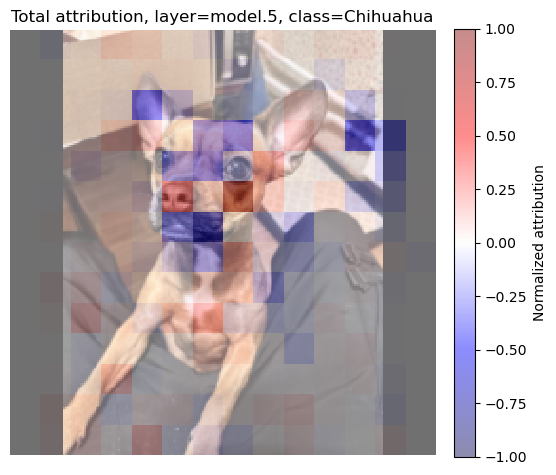

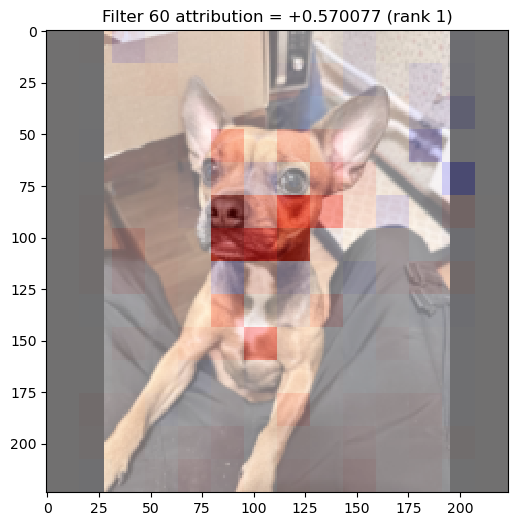

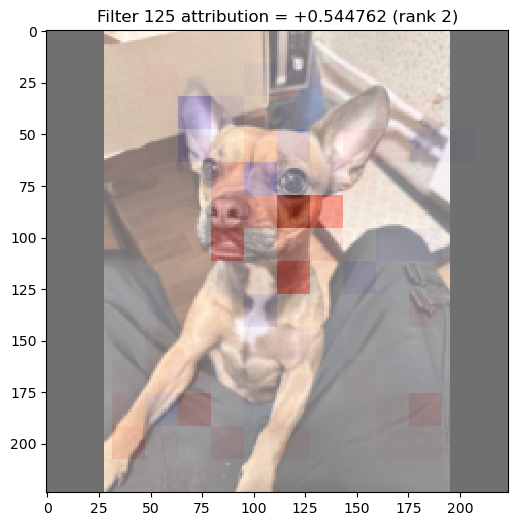

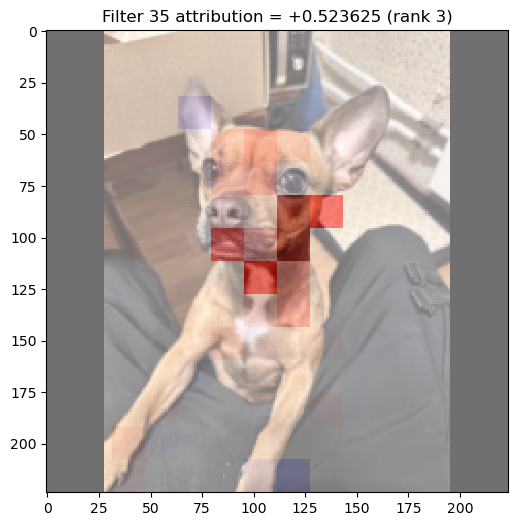

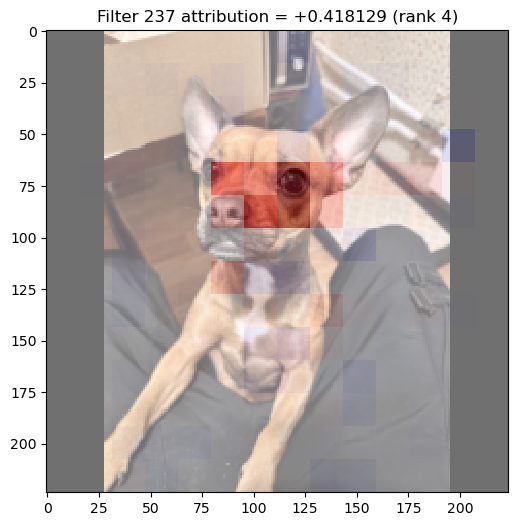

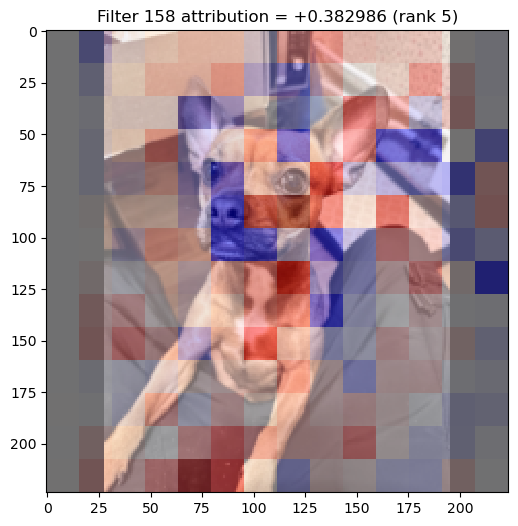

In [10]:
# Для классификатора предпоследний перед головой слой - 9
# Он слишком большой, 5 даёт достаточно хорошие признаки
result = run_attribution_pipeline(
    image_path="data/jess.jpg",
    layer_name='model.5',
    n_steps=30,
    top_n=5,
)

image: data/fox.jpg
layer: model.6
target class: 277 red_fox
target logit: 18.66610336303711
target softmax prob: 0.847356379032135
layer activation shape: (1, 256, 14, 14)
cond tensor shape: (1, 256, 14, 14)
filter_scores shape: (256,)

top filters by |attribution|:
 1. filter   73: +0.863783
 2. filter  137: +0.784330
 3. filter  208: +0.751542
 4. filter  223: +0.678745
 5. filter  241: +0.671189
 6. filter   43: +0.618559
 7. filter   29: +0.596336
 8. filter  197: +0.595992
 9. filter   75: +0.590788
10. filter  200: +0.506688

layer attribution sum: 4.8690009117126465
example neuron attribution: -2.928423100456712e-06
example filter attribution: 0.0965489074587822
F(x)            = 18.66610336303711
F(x0)           = 1.7859272956848145
F(x) - F(x0)    = 16.880176067352295
sum attribution = 4.8690009117126465
abs error       = 12.011175155639648


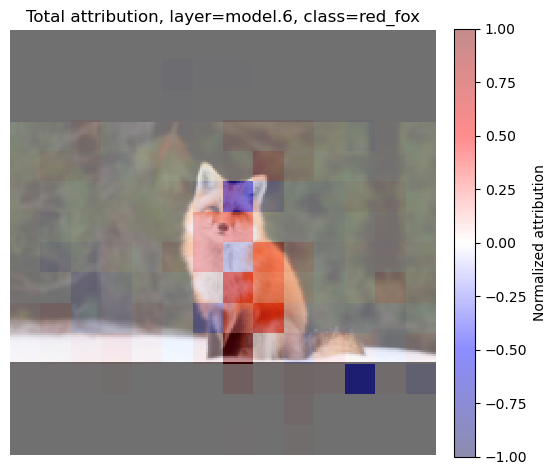

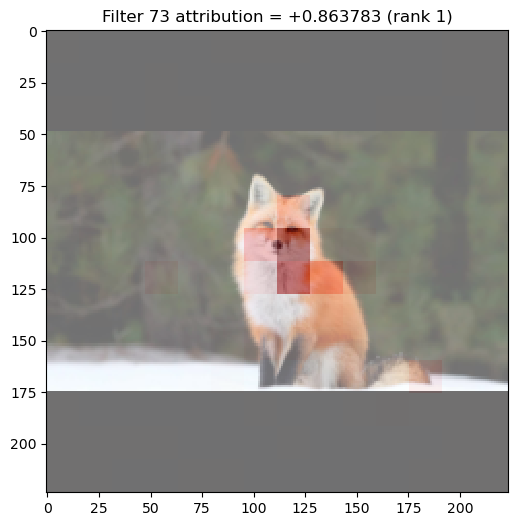

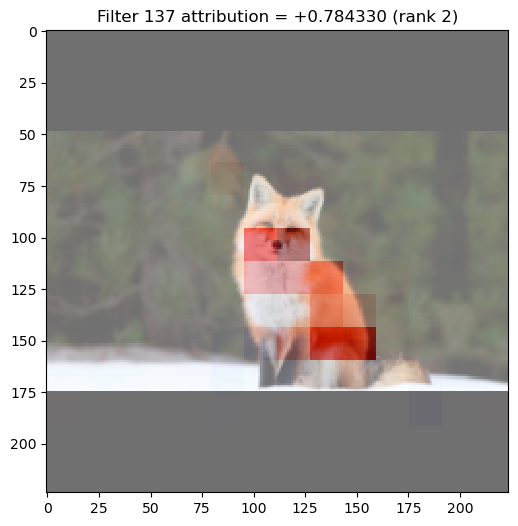

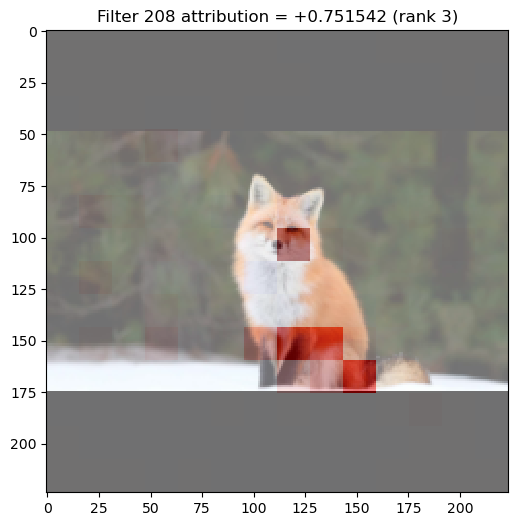

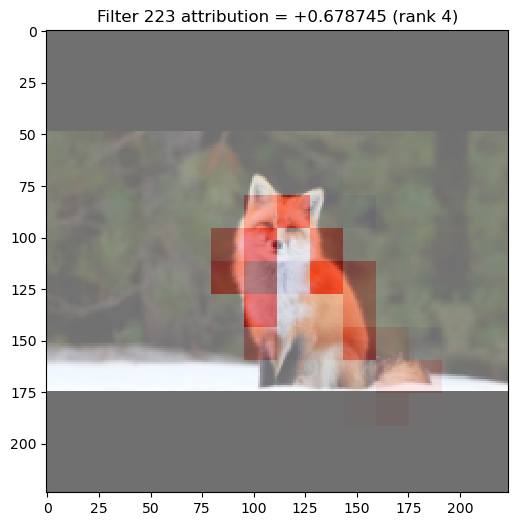

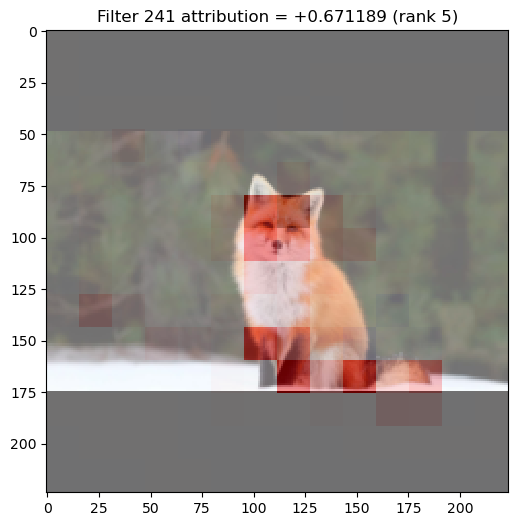

In [8]:
result = run_attribution_pipeline(
    image_path="data/fox.jpg",
    layer_name='model.6',
    n_steps=30,
    top_n=5,
)

### Запуск эксперимента: `fox.jpg` (слой `model.9`)
Сравниваем результаты на более глубоком слое и расширенном top-N фильтров.


image: data/fox.jpg
layer: model.9
target class: 277 red_fox
target logit: 18.66610336303711
target softmax prob: 0.847356379032135
layer activation shape: (1, 512, 7, 7)
cond tensor shape: (1, 512, 7, 7)
filter_scores shape: (512,)

top filters by |attribution|:
 1. filter  366: +2.876869
 2. filter  133: +1.347253
 3. filter  382: +1.291932
 4. filter   93: +0.896613
 5. filter   18: +0.827593
 6. filter   20: +0.728817
 7. filter  465: +0.690751
 8. filter  142: +0.636098
 9. filter  181: +0.633864
10. filter  308: +0.597548

layer attribution sum: 20.165000915527344
example neuron attribution: -0.0001595662033651024
example filter attribution: 0.1520712673664093
F(x)            = 18.66610336303711
F(x0)           = 1.7859272956848145
F(x) - F(x0)    = 16.880176067352295
sum attribution = 20.165000915527344
abs error       = 3.284824848175049


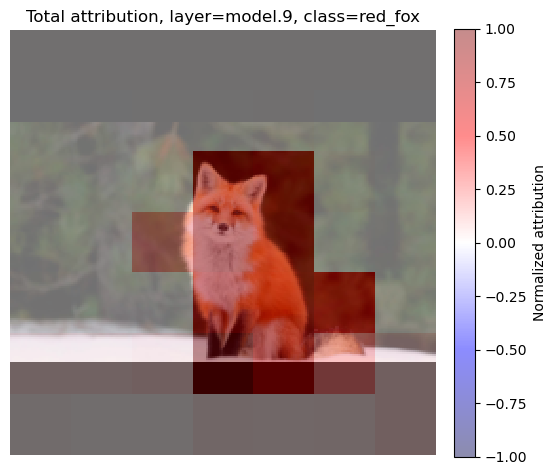

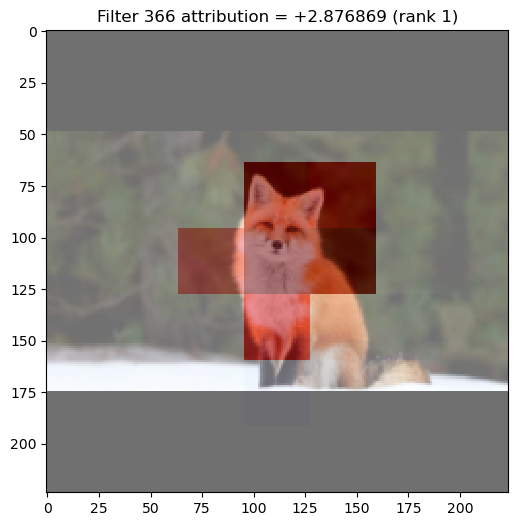

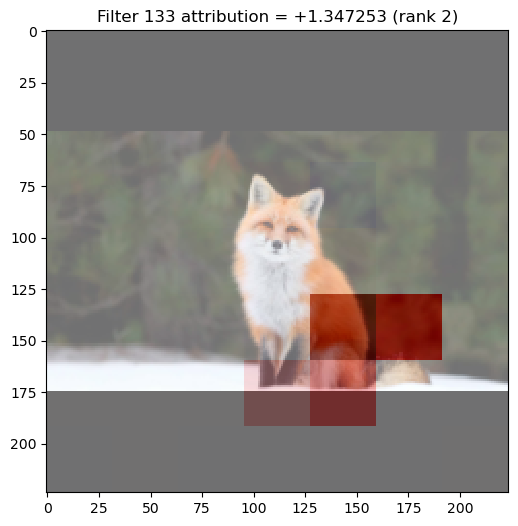

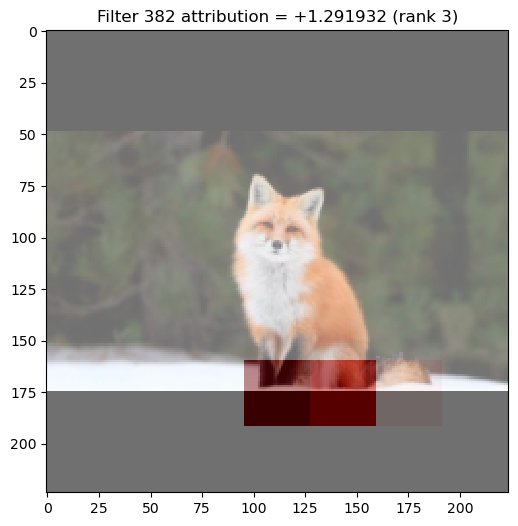

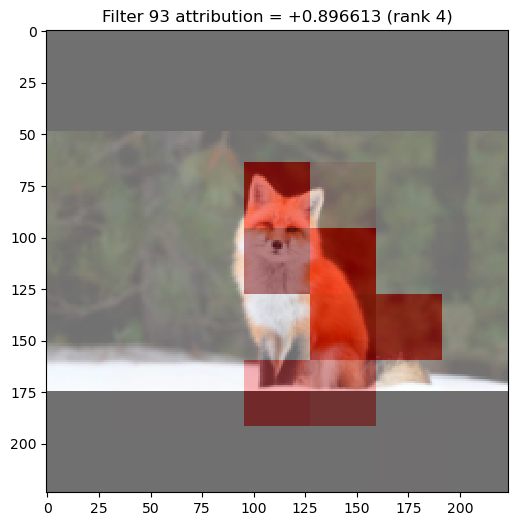

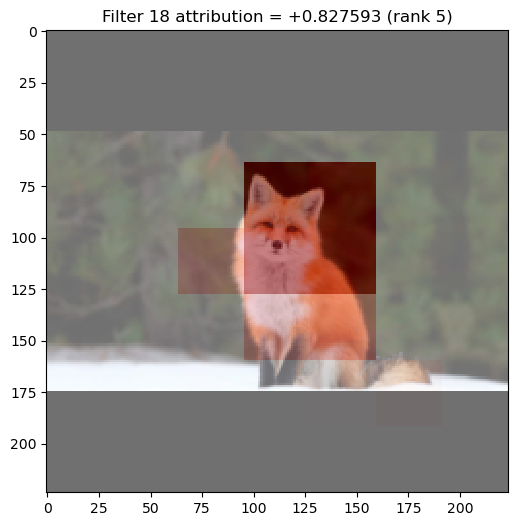

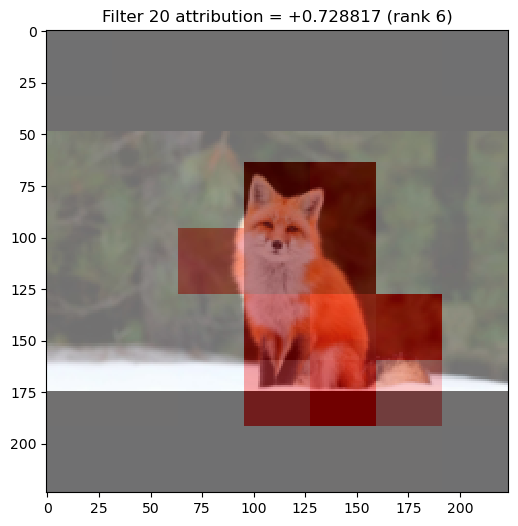

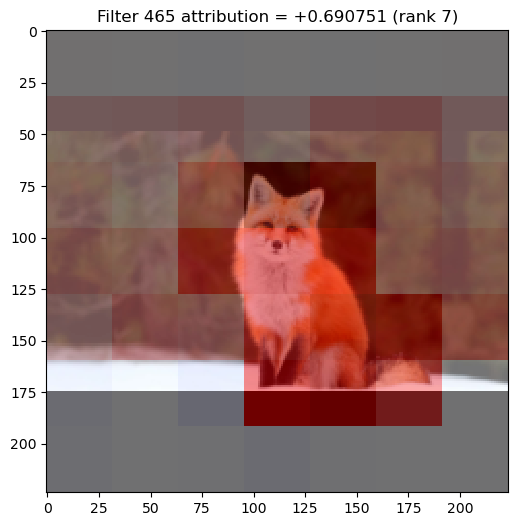

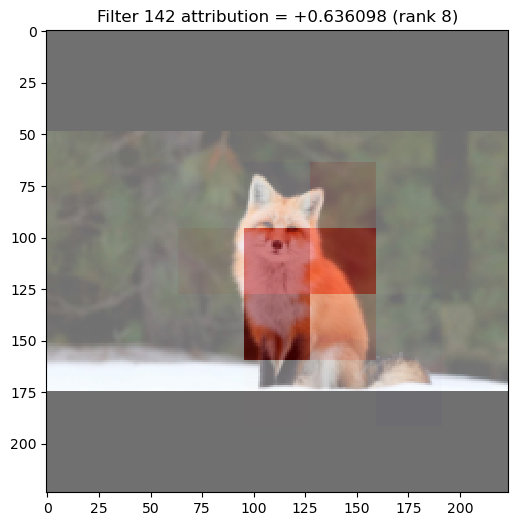

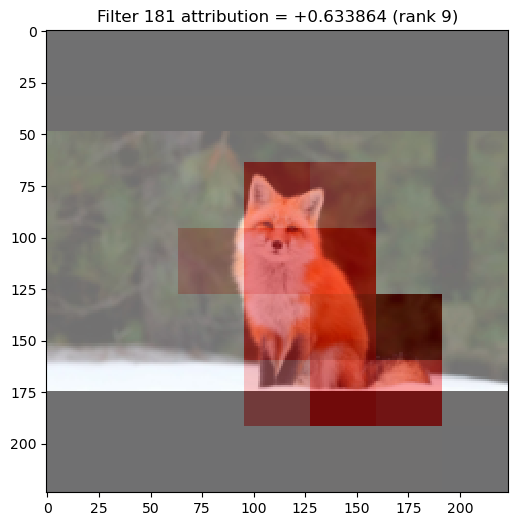

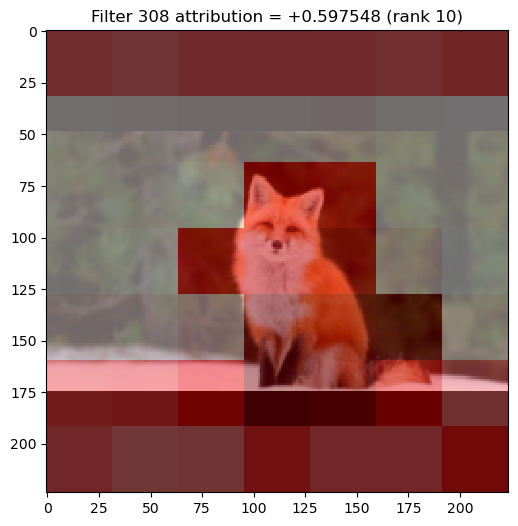

In [9]:
result = run_attribution_pipeline(
    image_path="data/fox.jpg",
    layer_name='model.9',
    n_steps=30,
    top_n=25,
)

### Запуск эксперимента: `lighthouse.jpg` (слой `model.6`)
Оцениваем важность нейронов для сцены с маяком на среднем уровне сети.


image: data/lighthouse.jpg
layer: model.6
target class: 437 beacon
target logit: 13.793744087219238
target softmax prob: 0.7471544742584229
layer activation shape: (1, 256, 14, 14)
cond tensor shape: (1, 256, 14, 14)
filter_scores shape: (256,)

top filters by |attribution|:
 1. filter   27: +0.599523
 2. filter   14: +0.466646
 3. filter   51: +0.446160
 4. filter  149: +0.400116
 5. filter   83: +0.392928
 6. filter   88: +0.342443
 7. filter  190: +0.339595
 8. filter   57: +0.308543
 9. filter  211: +0.281215
10. filter  144: +0.267805

layer attribution sum: -0.5857067108154297
example neuron attribution: -2.644236474225181e-06
example filter attribution: -0.012930318713188171
F(x)            = 13.793744087219238
F(x0)           = -0.3120385706424713
F(x) - F(x0)    = 14.10578265786171
sum attribution = -0.5857067108154297
abs error       = 14.69148936867714


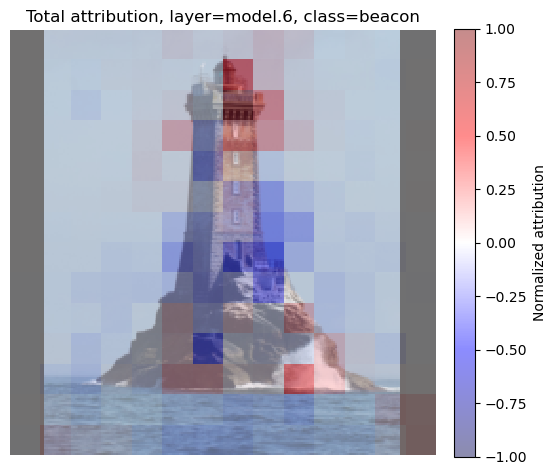

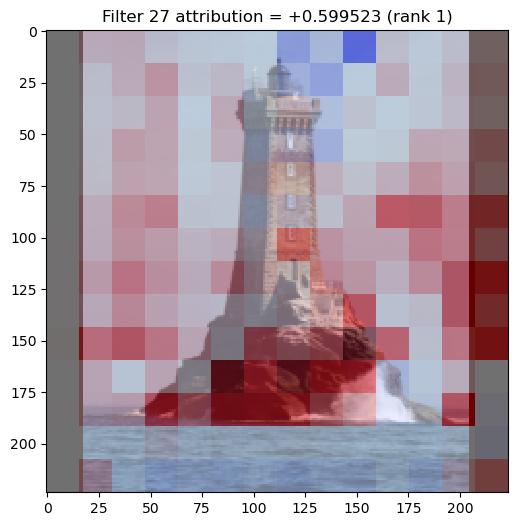

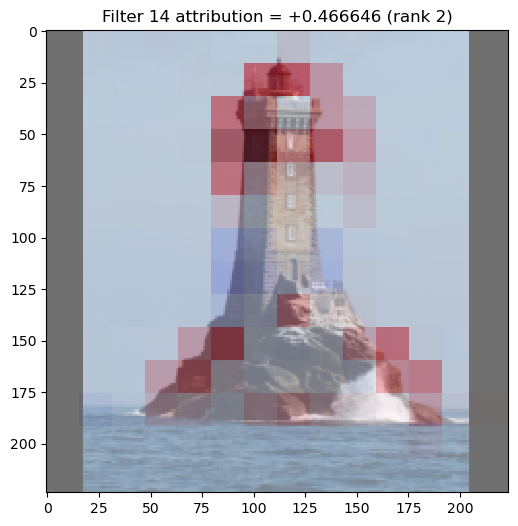

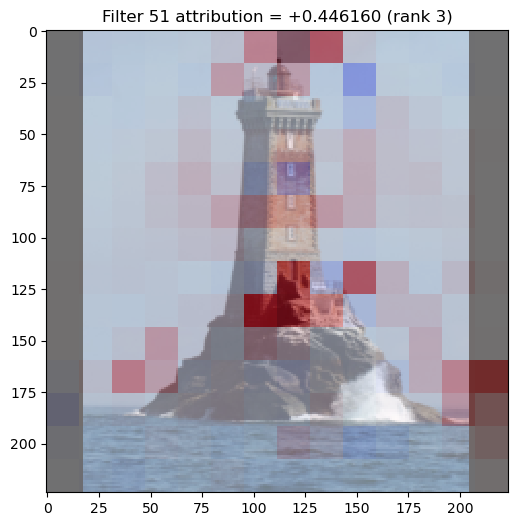

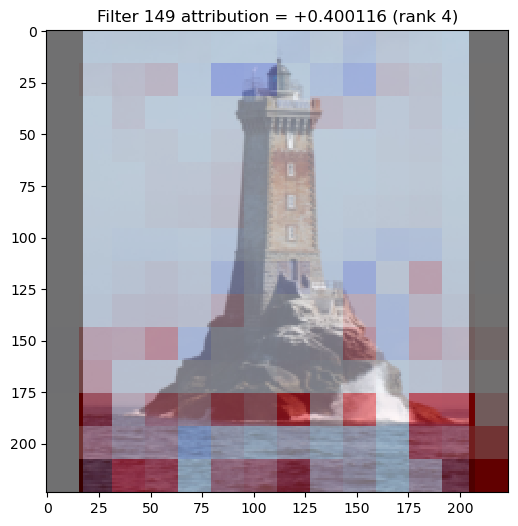

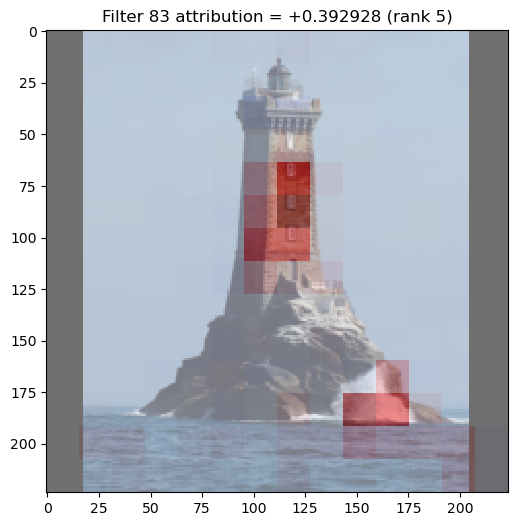

In [10]:
result = run_attribution_pipeline(
    image_path="data/lighthouse.jpg",
    layer_name='model.6',
    n_steps=30,
    top_n=5,
)

### Запуск эксперимента: `lighthouse.jpg` (слой `model.0`)
Смотрим attribution на раннем слое, чтобы сравнить с более глубокими представлениями.


image: data/lighthouse.jpg
layer: model.0
target class: 437 beacon
target logit: 13.793744087219238
target softmax prob: 0.7471544742584229
layer activation shape: (1, 32, 112, 112)
cond tensor shape: (1, 32, 112, 112)
filter_scores shape: (32,)

top filters by |attribution|:
 1. filter   29: +4.086740
 2. filter    3: +3.974320
 3. filter   23: +2.525921
 4. filter   28: +2.321461
 5. filter   14: +1.497353
 6. filter   17: +1.261443
 7. filter   25: +0.968152
 8. filter    1: +0.724269
 9. filter   16: +0.385111
10. filter   18: +0.247409

layer attribution sum: 10.0905122756958
example neuron attribution: 0.0
example filter attribution: -0.6281827688217163
F(x)            = 13.793744087219238
F(x0)           = -0.3120385706424713
F(x) - F(x0)    = 14.10578265786171
sum attribution = 10.0905122756958
abs error       = 4.015270382165909


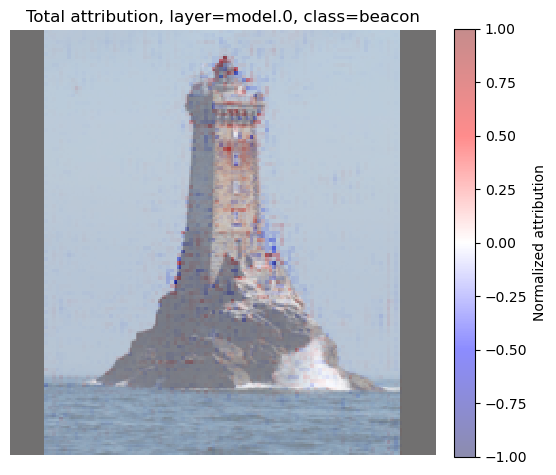

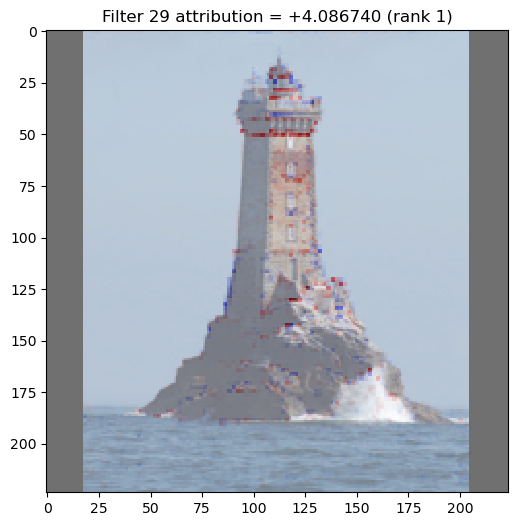

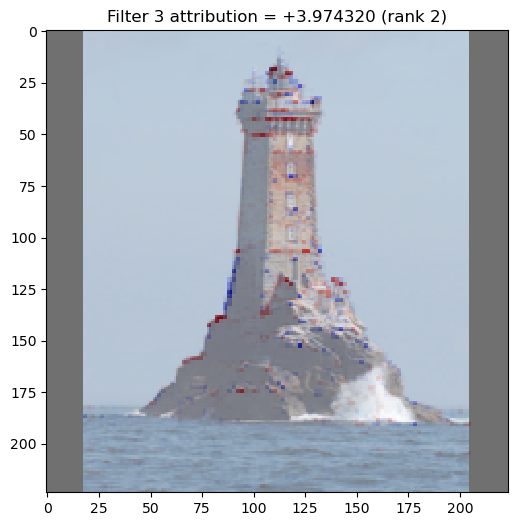

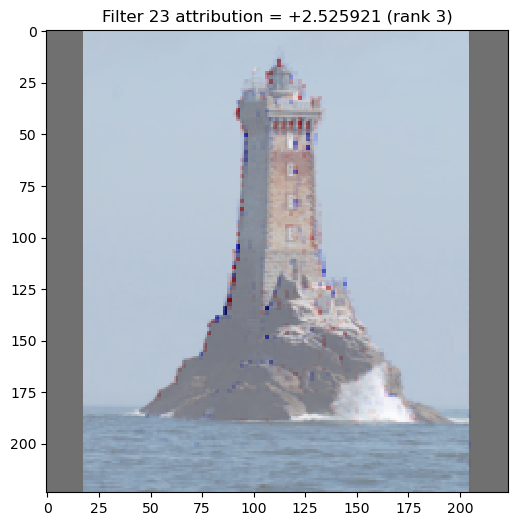

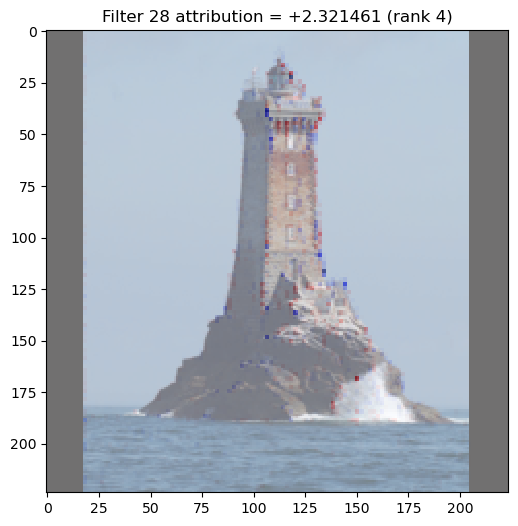

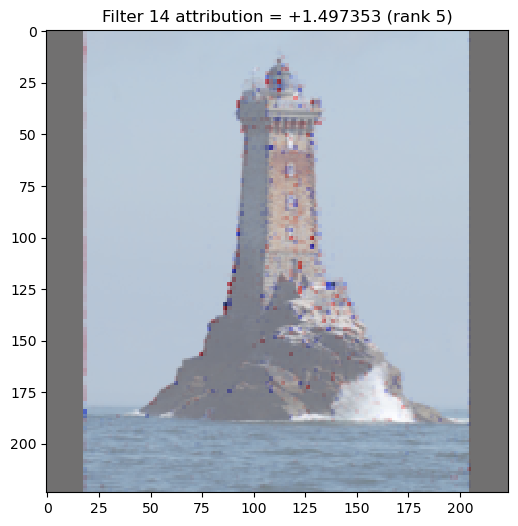

In [11]:
result = run_attribution_pipeline(
    image_path="data/lighthouse.jpg",
    layer_name='model.0',
    n_steps=30,
    top_n=5,
)

## Проверка сходимости ошибки

In [ ]:
step_grid = [32, 64, 128, 256, 512, 1024, 2048, 4096, 8192]
abs_errors = []
results_by_steps = {}

for n_steps in step_grid:
    print(f"\n=== n_steps = {n_steps} ===")
    result = run_attribution_pipeline(
        image_path="data/jess.jpg",
        layer_name='model.5',
        n_steps=n_steps,
        top_n=0,
    )
    abs_errors.append(result["abs_error"])
    results_by_steps[n_steps] = result


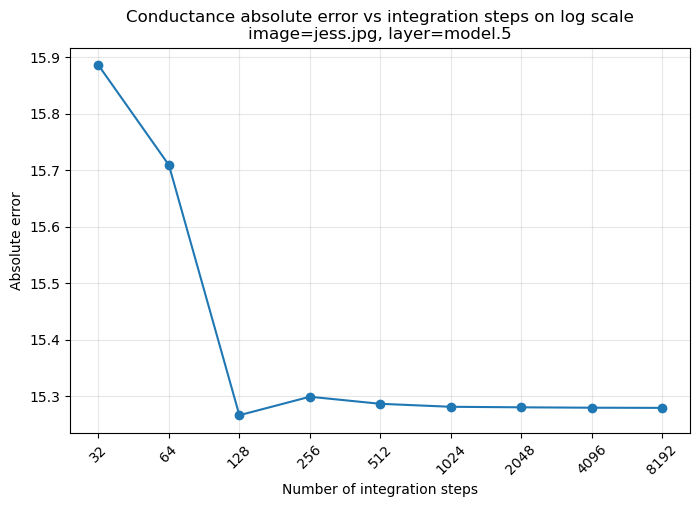


Summary:
n_steps=   32 | abs_error=15.8862179518
n_steps=   64 | abs_error=15.7094055414
n_steps=  128 | abs_error=15.2665935755
n_steps=  256 | abs_error=15.2993000746
n_steps=  512 | abs_error=15.2868145704
n_steps= 1024 | abs_error=15.2815338373
n_steps= 2048 | abs_error=15.2805815935
n_steps= 4096 | abs_error=15.2798842192
n_steps= 8192 | abs_error=15.2796105146


In [9]:
plt.figure(figsize=(8, 5))
plt.plot(step_grid, abs_errors, marker="o")
plt.xscale("log", base=2)
plt.xticks(step_grid, step_grid, rotation=45)
plt.xlabel("Number of integration steps")
plt.ylabel("Absolute error")
plt.title("Conductance absolute error vs integration steps on log scale\nimage=jess.jpg, layer=model.5")
plt.grid(True, which="both", alpha=0.3)
plt.show()

print("\nSummary:")
for n_steps, err in zip(step_grid, abs_errors):
    print(f"n_steps={n_steps:5d} | abs_error={err:.10f}")

## Эксперименты с ковариацией вынесены в отдельный ноутбук

Весь блок с zero-covariance diagnostics, segmented covariance analysis и regression benchmark перенесён в `[ImprovingAdvTransViaAttrib_covariance.ipynb](ImprovingAdvTransViaAttrib_covariance.ipynb)`.

Здесь оставлен только основной attribution pipeline из статьи, чтобы ноутбук не разрастался дальше.
